<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/nebulae_M42.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Orion Nebula (M42)**

https://en.m.wikipedia.org/wiki/Orion_Nebula

![ggg](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f3/Orion_Nebula_-_Hubble_2006_mosaic_18000.jpg/2048px-Orion_Nebula_-_Hubble_2006_mosaic_18000.jpg)

In [2]:
!pip install astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 33.7 MB/s eta 0:00:00


In [3]:
from astroquery.simbad import Simbad

# Query SIMBAD for information about the Orion Nebula
result_table = Simbad.query_object('M42')

# Print the results
print(result_table)

MAIN_ID    RA      DEC    RA_PREC ... COO_QUAL COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
        "h:m:s"  "d:m:s"          ...                                                             
------- -------- -------- ------- ... -------- -------------- ------------------- ----------------
  M  42 05 35 17 -05 23.4       4 ...        E              O 2017AstBu..72..257L                1


In [7]:
print(result_table.colnames)

['MAIN_ID', 'RA', 'DEC', 'RA_PREC', 'DEC_PREC', 'COO_ERR_MAJA', 'COO_ERR_MINA', 'COO_ERR_ANGLE', 'COO_QUAL', 'COO_WAVELENGTH', 'COO_BIBCODE', 'SCRIPT_NUMBER_ID']


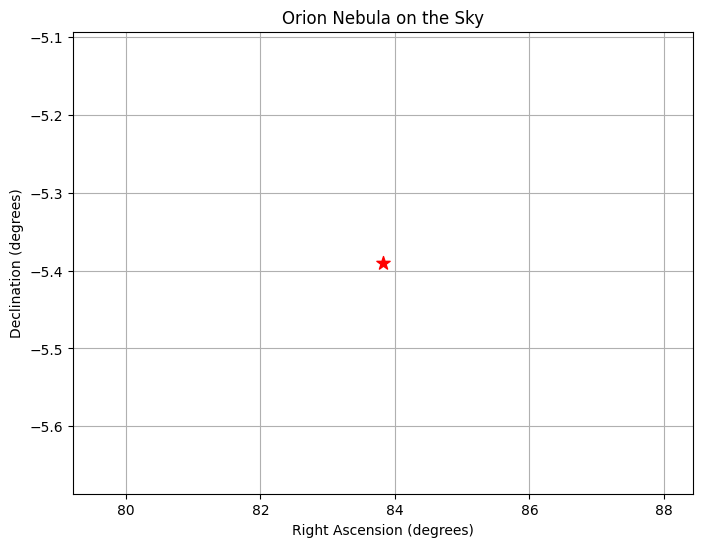

In [9]:
# Plotting on a sky chart: Show the Orion Nebula's location
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Create a SkyCoord object
orion_coord = SkyCoord(ra=ra, dec=dec, unit=(u.hourangle, u.deg))

# Simple plot
plt.figure(figsize=(8, 6))
plt.scatter(orion_coord.ra.deg, orion_coord.dec.deg, marker='*', s=100, color='red')
plt.xlabel('Right Ascension (degrees)')
plt.ylabel('Declination (degrees)')
plt.title('Orion Nebula on the Sky')
plt.grid(True)
plt.show()

# For a more detailed sky chart, consider using Aladin Sky Atlas:
# from astropy.coordinates import SkyCoord
# orion_coord = SkyCoord(ra=ra, dec=dec, unit=(u.hourangle, u.deg))
# orion_coord.to_string('hmsdms')  # Get a string suitable for Aladin

In [4]:
from astroquery.ipac.irsa import Irsa
from astroquery.sdss import SDSS
from astroquery.vizier import Vizier
import astropy.coordinates as coord
import astropy.units as u

In [5]:
from astropy.coordinates import SkyCoord

# Directly specify the coordinates for the Orion Nebula
orion_nebula = SkyCoord('05h35m17.3s', '-05d23m28s')

print(orion_nebula)

<SkyCoord (ICRS): (ra, dec) in deg
    (83.82208333, -5.39111111)>


In [6]:
# Coordinates for NGC 1499 (California Nebula)
m42_coords = coord.SkyCoord('05h35m17.3s -05d23m28s', frame='icrs')

# Query IRSA data from the spitzer.lvl_halpha catalog (IRAC/MIPS observations)
spitzer_halpha_data = Irsa.query_region(m42_coords, catalog='spitzer.lvl_halpha', spatial='Cone', radius=30*u.arcmin)

# Display the retrieved data
print(spitzer_halpha_data)

cntr  ra dec cra cdec naxis1 naxis2 ... band_name wavelength access_estsize s_fov tile  pt poly
---- --- --- --- ---- ------ ------ ... --------- ---------- -------------- ----- ---- --- ----
